In [ ]:
import os

os.environ['CUDA_VISIBLE_DEVICES'] = '3'    # GPU No.
from sampler.utils import *
print(dir())
import importlib
import sampler.utils
importlib.reload(sampler.utils)
from trainer.utils import restore_checkpoint
import torch
import torch.nn as nn
import json
from collections import namedtuple
from tqdm import tqdm
from models import get_model, get_ema
from sampler import VESDE
import numpy as np
from einops import rearrange

data_name = 'kol'
version = 'v1'      
opt_path = './results/' + data_name + '_' + version + '/config.json'
#FPE finetune
opt_path = './results/kol_v1_finetune_FPE/config.json'
with open(opt_path, 'r', encoding='utf-8') as f:
    opt = json.load(f)
    opt['num_channels'] = opt['num_components'] + opt['num_conditions']
OPT_class = namedtuple('OPT_class', opt.keys())
opt = OPT_class(**opt)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

['AnnealedLangevinDynamics', 'Corrector', 'EulerMaruyamaPredictor', 'F', 'ForwardEulerPredictor', 'ImprovedEulerPredictor', 'In', 'Kuramoto_Sivashinsky_equation', 'LangevinCorrector', 'LangevinCorrectorMM', 'NoneCorrector', 'NonePredictor', 'ODE_Solver', 'Out', 'Predictor', 'ReverseDiffusionPredictor', 'ReverseDiffusionPredictorMM', 'VESDE', 'VPSDE', 'Voronoi', '_', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__spec__', '__vsc_ipynb_file__', '_dh', '_i', '_i1', '_i2', '_ih', '_ii', '_iii', '_oh', 'abc', 'cKDTree', 'cal_correlation', 'cal_rmse', 'cal_water_attr', 'calculate_physics_residual_loss', 'calculate_physics_residual_loss_1d', 'calculate_physics_residual_loss_1d_2', 'calculate_physics_residual_loss_1d_3', 'calculate_physics_residual_loss_1d_4', 'calculate_physics_residual_loss_1d_full', 'calculate_physics_residual_loss_1d_p', 'calculate_physics_residual_loss_puvw', 'compute_acoustic_residual_torch', 'data_name', 'exit', 'funct

# Load pretrained model

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
net = get_model(opt)
#net = nn.DataParallel(net)
net.to(device)
ema = get_ema(net.parameters(), decay=opt.ema_rate)
optimizer = torch.optim.Adam(net.parameters(), lr=opt.lr, betas=(0.9, 0.999), eps=1e-8, weight_decay=0)
state = dict(optimizer=optimizer, model=net, ema=ema, epoch=0, iteration=0, loss_train=[])

ckpt_path = opt.results_path + '/checkpoint_517.pth'
#FPE finetune
ckpt_path ='./results/kol_v1_finetune_FPE/checkpoint_517.pth'

state = restore_checkpoint(ckpt_path, state, device)
net = state['model']
ema = state['ema']
ema.copy_to(net.parameters())
print('Model loaded from epoch', state['epoch'])

Model loaded from epoch 517


In [ ]:
import sys
import os
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

try:
    from fno import FNO2d
except ImportError:
    current_dir = os.getcwd()
    model_dir = os.path.join(current_dir, 'models')
    sys.path.append(model_dir) 
    try:
        from fno import FNO2d
    except ImportError:
        print("Warning: Could not import FNO2d. FNO generation might fail.")

# ================= [ADD] LNO Import Logic =================
try:
    from lno import LNO2d
except ImportError:
    current_dir = os.getcwd()
    model_dir = os.path.join(current_dir, 'models')
    sys.path.append(model_dir) 
    try:
        from lno import LNO2d
    except ImportError:
        print("Warning: Could not import LNO2d. LNO generation might fail.")

class LNOConfig:
    MODES = 16
    WIDTH = 8
    NUM_CHANNELS = 2
    SEQUENCE_LENGTH = 10 
    INPUT_RES = 6
    OUTPUT_RES = 64
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    MODEL_PATH = '/results_LNO/lno_reconstruction_2x.pth'



class FNOConfig:
    MODES = 16
    WIDTH = 64
    NUM_CHANNELS = 2
    SEQUENCE_LENGTH = 10 
    INPUT_RES = 6
    OUTPUT_RES = 64
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    MODEL_PATH = '/results_FNO/fno_reconstruction_2x.pth'

def get_grid(shape, device):
    batchsize, size_x, size_y = shape[0], shape[1], shape[2]
    gridx = torch.tensor(np.linspace(0, 1, size_x), dtype=torch.float)
    gridx = gridx.reshape(1, size_x, 1, 1).repeat([batchsize, 1, size_y, 1])
    gridy = torch.tensor(np.linspace(0, 1, size_y), dtype=torch.float)
    gridy = gridy.reshape(1, 1, size_y, 1).repeat([batchsize, size_x, 1, 1])
    return torch.cat((gridx, gridy), dim=-1).to(device)

def load_fno_model(config, path_override=None):
    model = FNO2d(
        num_channels=config.NUM_CHANNELS,
        out_channels=config.NUM_CHANNELS * config.SEQUENCE_LENGTH,
        modes1=config.MODES,
        modes2=config.MODES,
        width=config.WIDTH,
        initial_step=config.SEQUENCE_LENGTH
    ).to(config.DEVICE)
    
    path = path_override if path_override else config.MODEL_PATH
    if not os.path.exists(path):
        path = os.path.join('results', config.MODEL_PATH)
    
    if os.path.exists(path):
        state_dict = torch.load(path, map_location=config.DEVICE)
        model.load_state_dict(state_dict)
        print(f"FNO Model loaded from {path}")
    else:
        print(f"Warning: FNO Model not found at {path}")
    
    model.eval()
    return model

# ================= [ADD] LNO Loader Function =================
def load_lno_model(config, path_override=None):
    tx = torch.linspace(0, 1, config.OUTPUT_RES).unsqueeze(0).to(config.DEVICE)
    ty = torch.linspace(0, 1, config.OUTPUT_RES).unsqueeze(0).to(config.DEVICE)

    model = LNO2d(
        in_channels=config.NUM_CHANNELS * config.SEQUENCE_LENGTH,
        out_channels=config.NUM_CHANNELS * config.SEQUENCE_LENGTH,
        width=config.WIDTH,
        modes1=config.MODES,
        modes2=config.MODES,
        tx=tx, 
        ty=ty
    ).to(config.DEVICE)
    
    path = path_override if path_override else config.MODEL_PATH
    if not os.path.exists(path):
        path = os.path.join('results', config.MODEL_PATH) # Fallback check
    
    if os.path.exists(path):
        state_dict = torch.load(path, map_location=config.DEVICE)
        model.load_state_dict(state_dict)
        print(f"LNO Model loaded from {path}")
    else:
        print(f"Warning: LNO Model not found at {path}")
    
    model.eval()
    return model

def cal_rmse_curve(gt, pred, normalize=True):
    T = gt.shape[0]
    errors = []
    for t in range(T):
        diff = gt[t] - pred[t]
        mse = np.mean(diff**2)
        rmse = np.sqrt(mse)
        if normalize:
            rmse /= (np.max(gt[t]) - np.min(gt[t]) + 1e-6)
        errors.append(rmse)
    return np.array(errors)

def vor_cal_batch_numpy(u, image_size=64, range_val=[0, 2*np.pi]):
    # u shape: (B, T, 2, H, W) or (T, H, W, 2) -> output (B, T, H, W)
    if u.shape[-1] == 2: # (..., H, W, 2)
        u = u.transpose(0, 3, 1, 2) if len(u.shape)==4 else u.transpose(0, 4, 1, 2, 3) # -> (..., 2, H, W)

    u_torch = torch.tensor(u).float()
    h = (range_val[1] - range_val[0]) / image_size
    
    dudy = (torch.roll(u_torch[:, :, 0, :, :], -1, dims=-2) - torch.roll(u_torch[:, :, 0, :, :], 1, dims=-2)) / (2 * h)
    dvdx = (torch.roll(u_torch[:, :, 1, :, :], -1, dims=-1) - torch.roll(u_torch[:, :, 1, :, :], 1, dims=-1)) / (2 * h)
    
    vort = dvdx - dudy
    return vort.numpy()

# Load test data

In [8]:
data_test_path = "./data/kolmogorov_flow_test.npy"
scalar_path = opt.results_path + '/scalar.npy'
data_raw = np.load(data_test_path)
rey = np.array([50, 125, 575, 1100, 1500])
sigma = np.array([2, 4, 6, 8])
_, z = np.meshgrid(np.linspace(0, 2 * np.pi, opt.image_size, endpoint=False),
                    np.linspace(0, 2 * np.pi, opt.image_size, endpoint=False), indexing='ij')
x_test = data_raw.reshape(5, -1, 400, 64, 64, 2)
mean, std = np.load(scalar_path)
scalar = lambda x: (x-mean)/std
scalar_inv = lambda x: x*std+mean
print(x_test.shape)

(5, 4, 400, 64, 64, 2)


# Load test data

In [9]:
m           =   2                                       # overlap
T           =   opt.num_frames                          # number of frames within a single sample
T_prime     =   100                                      # length of frames you want to generate   350
B           =   int(np.ceil((T_prime-m) / (T - m)))     # number of samples for parallel generation
T_prime     =   B * (T - m) + m                         # the total length might be a little longer than the given length
n_samples   =   1                                       # batch size

samples = []
seed_samples = 2
rnd = np.random.RandomState(seed_samples)
num_re = len(x_test)
num_k = len(x_test[0])
s_re, s_k = 4, 1

'''experimental samples'''
indices = []
for i_re, tr_k in enumerate(x_test):
    for i_k, tr in enumerate(tr_k):
        rnd = np.random.RandomState(seed_samples+i_re*num_re+i_k)
        i_steps = rnd.choice(len(tr) - T - T_prime - 10,
                                n_samples, replace=False)+10
        indices.append(i_steps)
        for i in i_steps:
            single_sample = x_test[i_re, i_k, i:i + T_prime].transpose(0, 3, 1, 2)
            f = np.sin(sigma[i_k] * z)[np.newaxis, np.newaxis].repeat(T_prime, axis=0)
            r = (1./rey[i_re]*100. * np.ones_like(f))
            samples.append(np.concatenate([single_sample, f, r], axis=1))
samples = np.stack(samples, axis=0)         # b*(t*c+2)*h*w
indices = np.array(indices).reshape(num_re, num_k, -1)
samples = samples[[s_re*num_k+s_k]]
print(samples.shape)

(1, 106, 4, 64, 64)


# Reconstruction

In [ ]:
outer_loop = 100   
seed_sample = 123
denoising_steps = 100
obs_type = 'regular'     # 'random', 'regular', 'forecast'
scale = 6               

alpha_case = 0.5
beta = 0.4
gamma = 0.5

sde = VESDE(opt, sigma_min=opt.beta_min, sigma_max=opt.beta_max, N=outer_loop)
sde1 = VESDE(opt, sigma_min=opt.beta_min, sigma_max=opt.beta_max, N=denoising_steps)
net.eval()
reap_fn = lambda x, num: torch.stack([x for _ in range(num)])

setup_seed(seed_sample)
with torch.no_grad():
    if obs_type.lower() == 'random':
        T_prime_y = T_prime
        mask = np.zeros([opt.num_components+opt.num_conditions, opt.image_size, opt.image_size])
        mask[:opt.num_components] = mask_gen([1, opt.image_size, opt.image_size], scale, seed=seed_samples)
        mask_torch = torch.from_numpy(mask).to(device)
        transform_gen = transform = lambda x:x[:, :T_prime_y]*mask[np.newaxis, np.newaxis] if isinstance(x, np.ndarray) else x[:, :T_prime_y]*mask_torch[None, None].to(x.device)
        sparsity = scale
    elif obs_type.lower() == 'regular':
        T_prime_y = T_prime
        transform_gen = transform = lambda x:x[:, :T_prime_y, :2, ::scale, ::scale]
        sparsity = 1-1/scale**2
    elif obs_type.lower() == 'forecast':
        T_prime_y = 0
        transform_gen = transform = lambda x:x[:, :scale]
        sparsity = 1-scale/T

    alpha = alpha_case/np.sqrt(1-sparsity)
    
    samples_scale = samples.copy()
    samples_scale[:, :, :opt.num_components] = scalar(samples_scale[:, :, :opt.num_components])
    y = transform_gen(samples_scale)
    print(f"Observation y shape: {y.shape}")

    latent_mask = torch.ones([T, 1, 1, 1]).float().to(device)
    obs_mask = torch.zeros([T, 1, 1, 1]).float().to(device)
    frame_indices = torch.arange(T).to(device)
    net_fn = lambda x, t: net(x, x0=x, timesteps=t, latent_mask=reap_fn(latent_mask, len(x)), obs_mask=reap_fn(obs_mask, len(x)), frame_indices=reap_fn(frame_indices, len(x)))[0]

    print("Running SDE generation...")
    x_inpainted = s3gm_sample_2d(opt, net_fn, sde, y,
                              transform_gen,
                              alpha=alpha, beta=beta, gamma=gamma,
                              T_prime_y=T_prime_y, T_prime=T_prime, overlap=m,
                              corrector=NoneCorrector,
                              n_steps=0,
                              snr=0.128, device=device, dtype='float', eps=1e-12,
                              probability_flow=False, continuous=True)                    
    x_pred = x_inpainted.copy()

    print("Running ISS generation...")
    setup_seed(seed_sample)


    x_inpainted1 = MRSM_sample_2d_ISS_kol(
                        opt, net_fn, sde1, y, transform_gen,
                        alpha=1/np.sqrt(1-sparsity), beta=beta, gamma=gamma,
                        T_prime_y=T_prime_y, T_prime=T_prime, overlap=m,
                        corrector=NoneCorrector, n_steps=0, eta=0, 
                        reg_coef_pa = 20*T_prime, reg_coef_ar = 0,
                        denoising_steps=denoising_steps, snr=0.128, device=device, dtype='float', eps=1e-12,
                        probability_flow=False, continuous=True)
    x_pred1 = x_inpainted1.copy()

    print("Running LNO generation (x_pred2)...")
    try:
        lno_cfg = LNOConfig()
        model_path = 'results_LNO/lno_reconstruction_6x.pth'
        lno_model = load_lno_model(lno_cfg, path_override=model_path)

        gt_input_lno = torch.tensor(samples_scale[:, :, :2], dtype=torch.float).to(lno_cfg.DEVICE)
        
        SEQ_LEN = lno_cfg.SEQUENCE_LENGTH
        TARGET_LEN = T_prime
        num_chunks = int(np.ceil(TARGET_LEN / SEQ_LEN))
        
        pred_lno_list = []
        
        for i in range(num_chunks):
            chunk_start = i * SEQ_LEN
            chunk_end = chunk_start + SEQ_LEN
            actual_end = min(chunk_end, gt_input_lno.shape[1])
            
            # chunk shape: (B, T_chunk, C, H, W)
            chunk_data = gt_input_lno[:, chunk_start:actual_end, ...]
            
            # Padding if needed
            curr_len = chunk_data.shape[1]
            pad_len = 0
            if curr_len < SEQ_LEN:
                pad_len = SEQ_LEN - curr_len
                # Pad shape matches chunk_data
                padding = torch.zeros(chunk_data.shape[0], pad_len, 2, 64, 64).to(lno_cfg.DEVICE)
                chunk_data_padded = torch.cat([chunk_data, padding], dim=1)
            else:
                chunk_data_padded = chunk_data
            
            # data: (B, T, C, H, W) -> downsample H, W
            x_low = chunk_data_padded[:, :, :, ::lno_cfg.INPUT_RES, ::lno_cfg.INPUT_RES]
            
            B_sz, T_ch, C_ch, H_l, W_l = x_low.shape
            # Reshape for interpolate: (B*T, C, H, W)
            x_in = x_low.reshape(B_sz * T_ch, C_ch, H_l, W_l)
            x_in = F.interpolate(x_in, size=(lno_cfg.OUTPUT_RES, lno_cfg.OUTPUT_RES), mode='bilinear', align_corners=True)
            
            x_in_lno = x_in.reshape(B_sz, T_ch, C_ch, lno_cfg.OUTPUT_RES, lno_cfg.OUTPUT_RES)
            x_in_lno = x_in_lno.reshape(B_sz, T_ch * C_ch, lno_cfg.OUTPUT_RES, lno_cfg.OUTPUT_RES)
            
            out_lno = lno_model(x_in_lno) # Output: (B, T*C, H, W)
            
            out_lno = out_lno.reshape(B_sz, T_ch, C_ch, lno_cfg.OUTPUT_RES, lno_cfg.OUTPUT_RES)
            
            if pad_len > 0:
                out_lno = out_lno[:, :-pad_len, ...]
            
            pred_lno_list.append(out_lno)
            
        pred_seq_lno = torch.cat(pred_lno_list, dim=1) # (B, T, C, H, W)
        x_pred2_uv = pred_seq_lno.cpu().numpy()
        
        x_pred2 = np.zeros_like(x_pred)
        x_pred2[:, :, :2] = x_pred2_uv
        x_pred2[:, :, 2:] = samples_scale[:, :x_pred2.shape[1], 2:]
        
    except Exception as e:
        print(f"LNO inference failed: {e}")
        import traceback
        traceback.print_exc()
        x_pred2 = np.zeros_like(x_pred)


    print("Running FNO generation...")
    try:
        fno_cfg = FNOConfig()
        model_path = 'results_FNO/fno_reconstruction_6x.pth'
        
        fno_model = load_fno_model(fno_cfg, path_override=model_path)
        
        gt_input = torch.tensor(samples_scale[:, :, :2], dtype=torch.float).permute(0, 1, 3, 4, 2).to(fno_cfg.DEVICE)
        
        SEQ_LEN = fno_cfg.SEQUENCE_LENGTH
        TARGET_LEN = T_prime
        num_chunks = int(np.ceil(TARGET_LEN / SEQ_LEN))
        
        pred_seq_list = []
        
        for i in range(num_chunks):
            chunk_start = i * SEQ_LEN
            chunk_end = chunk_start + SEQ_LEN
            actual_end = min(chunk_end, gt_input.shape[1])
            
            chunk_data = gt_input[:, chunk_start:actual_end, ...]
            curr_len = chunk_data.shape[1]
            pad_len = 0
            if curr_len < SEQ_LEN:
                pad_len = SEQ_LEN - curr_len
                padding = torch.zeros(chunk_data.shape[0], pad_len, 64, 64, 2).to(fno_cfg.DEVICE)
                chunk_data_padded = torch.cat([chunk_data, padding], dim=1)
            else:
                chunk_data_padded = chunk_data
            
            x_low = chunk_data_padded[:, :, ::fno_cfg.INPUT_RES, ::fno_cfg.INPUT_RES, :]
            B_sz, T_ch, H_l, W_l, C_ch = x_low.shape

            x_in = x_low.reshape(B_sz * T_ch, H_l, W_l, C_ch).permute(0, 3, 1, 2)
            x_in = F.interpolate(x_in, size=(fno_cfg.OUTPUT_RES, fno_cfg.OUTPUT_RES), mode='bilinear', align_corners=True)
            x_in = x_in.reshape(B_sz, T_ch, C_ch, fno_cfg.OUTPUT_RES, fno_cfg.OUTPUT_RES).permute(0, 3, 4, 1, 2).reshape(B_sz, fno_cfg.OUTPUT_RES, fno_cfg.OUTPUT_RES, T_ch * C_ch)
            
            grid = get_grid(x_in.shape, fno_cfg.DEVICE)
            out = fno_model(x_in, grid).squeeze(-2)
            
            out = out.view(B_sz, fno_cfg.OUTPUT_RES, fno_cfg.OUTPUT_RES, T_ch, C_ch).permute(0, 3, 1, 2, 4)
            if pad_len > 0:
                out = out[:, :-pad_len, ...]
            pred_seq_list.append(out)
            
        pred_seq = torch.cat(pred_seq_list, dim=1) # (B, T, H, W, C)
        x_pred3_uv = pred_seq.permute(0, 1, 4, 2, 3).cpu().numpy()
        
        x_pred3 = np.zeros_like(x_pred)
        x_pred3[:, :, :2] = x_pred3_uv
        x_pred3[:, :, 2:] = samples_scale[:, :x_pred3.shape[1], 2:] # Copy extra channels from GT

    except Exception as e:
        print(f"FNO inference failed: {e}")
        x_pred3 = np.zeros_like(x_pred)


x_pred[:, :, :opt.num_components] = scalar_inv(x_pred[:, :, :opt.num_components])
x_pred1[:, :, :opt.num_components] = scalar_inv(x_pred1[:, :, :opt.num_components])
x_pred2[:, :, :opt.num_components] = scalar_inv(x_pred2[:, :, :opt.num_components]) # [ADD]
x_pred3[:, :, :opt.num_components] = scalar_inv(x_pred3[:, :, :opt.num_components])

vor_pred = vor_cal_batch(np.concatenate([x_pred[0, :, 1:2], x_pred[0, :, :1]], axis=1), opt.image_size, [0, 2*np.pi])
vor_ref = vor_cal_batch(np.concatenate([samples[0, :, 1:2], samples[0, :, :1]], axis=1), opt.image_size, [0, 2*np.pi])

vor_pred1 = vor_cal_batch(np.concatenate([x_pred1[0, :, 1:2], x_pred1[0, :, :1]], axis=1), opt.image_size, [0, 2*np.pi])
vor_pred2 = vor_cal_batch(np.concatenate([x_pred2[0, :, 1:2], x_pred2[0, :, :1]], axis=1), opt.image_size, [0, 2*np.pi])
vor_pred3 = vor_cal_batch(np.concatenate([x_pred3[0, :, 1:2], x_pred3[0, :, :1]], axis=1), opt.image_size, [0, 2*np.pi])

errors = cal_rmse(samples[0, :, 0:2, :], x_pred[0, :, 0:2, :], normalize=True)
mean_error = np.mean(errors)
print(f'mean_error (SDE): {mean_error:.4f}')

errors1 = cal_rmse(samples[0, :, 0:2, :], x_pred1[0, :, 0:2, :], normalize=True)
mean_error1 = np.mean(errors1)
print(f'mean_error1 (ISS): {mean_error1:.4f}')

errors2 = cal_rmse(samples[0, :, 0:2, :], x_pred2[0, :, 0:2, :], normalize=True)
mean_error2 = np.mean(errors2)
print(f'mean_error2 (LNO): {mean_error2:.4f}')

errors3 = cal_rmse(samples[0, :, 0:2, :], x_pred3[0, :, 0:2, :], normalize=True)
mean_error3 = np.mean(errors3)
print(f'mean_error3 (FNO): {mean_error3:.4f}')

num_T = x_pred.shape[1]
print(f'Number of generated snapshots: {num_T}')
torch.cuda.empty_cache()

Observation y shape: (1, 106, 2, 11, 11)
Running SDE generation...


loss total: 5.07313e+02 | loss obs.: 1.32381e+01 | loss consis.: 2.36103e+02: 100%|██████████| 100/100 [00:11<00:00,  8.66it/s]


Running ISS generation...


SDE | loss total: 2.99770e+03 | loss obs.: 1.73757e+02 | loss consis.: 7.55313e+01 | reg_loss.: 2.74462e+03: 100%|██████████| 100/100 [00:11<00:00,  8.65it/s]
SDE | loss total: 6.60365e+02 | loss obs.: 1.75361e+01 | loss consis.: 2.32379e+01 | reg_loss.: 6.17384e+02: 100%|██████████| 100/100 [00:11<00:00,  8.70it/s]


Running LNO generation (x_pred2)...
LNO Model loaded from results_LNO/lno_reconstruction_6x.pth
Running FNO generation...
FNO Model loaded from results_FNO/fno_reconstruction_6x.pth
mean_error (SDE): 0.1339
mean_error1 (ISS): 0.0459
mean_error2 (LNO): 0.4038
mean_error3 (FNO): 0.1293
Number of generated snapshots: 106


# Visualization

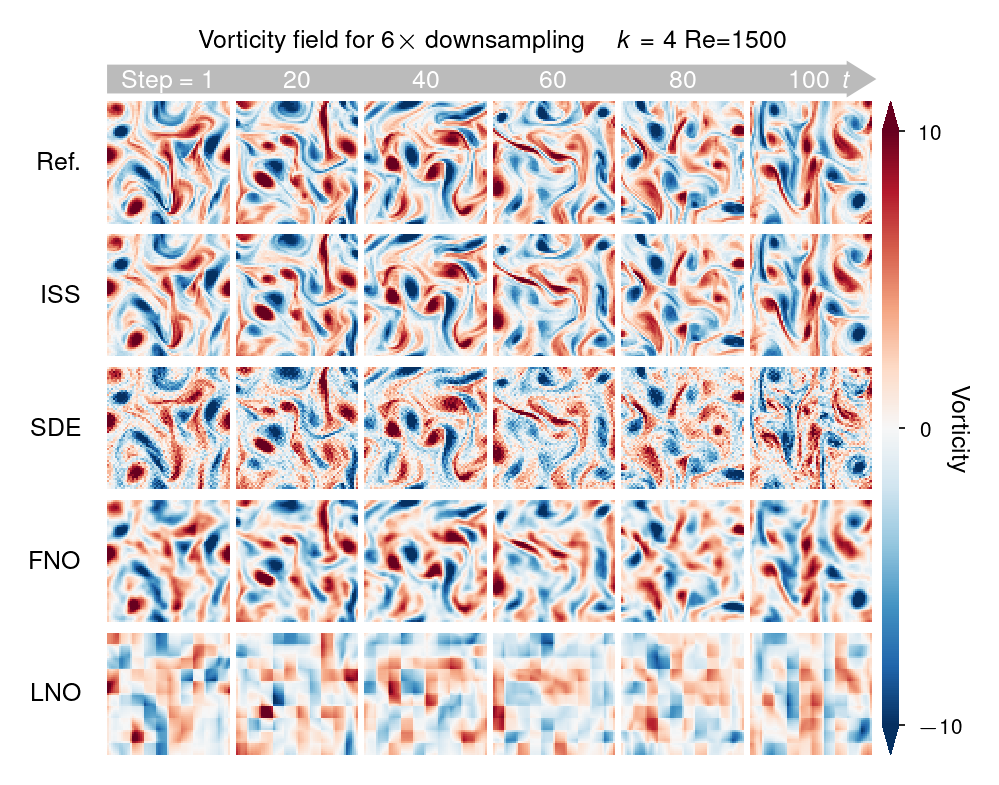

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib as mpl
import os

TARGET_WIDTH_INCH = 7 / 2.54  
DPI_FOR_PUBLICATION = 300 

UNIFORM_FONT_SIZE = 6      

try:
    mpl.rcParams['text.usetex'] = True
    
    mpl.rcParams['text.latex.preamble'] = r'''
        \usepackage{amsmath}
        \usepackage{amsfonts}
        \usepackage{amssymb}
        \usepackage{helvet}
        \renewcommand{\familydefault}{\sfdefault}
        \usepackage{sansmath} 
        \sansmath
    '''
    
    mpl.rcParams['font.family'] = 'sans-serif'
    mpl.rcParams['font.sans-serif'] = ['Helvetica', 'Arial']
    
except:
    print("Warning: LaTeX not found, falling back to standard rendering.")
    mpl.rcParams['text.usetex'] = False
    mpl.rcParams['font.family'] = 'sans-serif'

mpl.rcParams['axes.linewidth'] = 0.5       
mpl.rcParams['xtick.major.width'] = 0.4   
mpl.rcParams['ytick.major.width'] = 0.4
mpl.rcParams['font.size'] = UNIFORM_FONT_SIZE
mpl.rcParams['axes.labelsize'] = UNIFORM_FONT_SIZE
mpl.rcParams['xtick.labelsize'] = UNIFORM_FONT_SIZE
mpl.rcParams['ytick.labelsize'] = UNIFORM_FONT_SIZE
mpl.rcParams['legend.fontsize'] = UNIFORM_FONT_SIZE


def plot_vorticity_field_styled(fields, row, col, row_labels=None, col_labels=None, 
                                title=None, cbar_label="Vorticity", 
                                dpi=DPI_FOR_PUBLICATION, q_range=None, save_fig=None):

    SCALE_FACTOR = TARGET_WIDTH_INCH / (col * 1.5 + 2.5)
    
    figsize_width = TARGET_WIDTH_INCH 
    figsize_height = (row * 1.5 + 1.8) * SCALE_FACTOR * 1.2 
    
    fig, axes = plt.subplots(row, col, figsize=(figsize_width, figsize_height), dpi=dpi)
    
    plt.subplots_adjust(left=0.08 * SCALE_FACTOR * 2.0, 
                        right=1.0 - (0.15 * SCALE_FACTOR), 
                        top=0.88, 
                        bottom=0.06, 
                        wspace=0.05, hspace=0.05)

    if fields.ndim == 3:
        fields = fields.reshape(row, col, *fields.shape[1:])
    
    im = None 
    H, W = fields.shape[2], fields.shape[3]

    for i in range(row):
        for j in range(col):
            field = fields[i, j]
            ax = axes[i, j]
            im = ax.pcolormesh(field, cmap='RdBu_r', rasterized=True)
            
            if q_range is not None:
                im.set_clim(q_range)
            
            ax.set_xlim(0, W)
            ax.set_ylim(0, H)
            ax.set_aspect('equal')
            ax.axis('off')
            
            if j == 0 and row_labels is not None and i < len(row_labels):
                ax.text(-0.2, 0.5, row_labels[i], 
                        transform=ax.transAxes, 
                        fontsize=UNIFORM_FONT_SIZE, 
                        va='center', 
                        ha='right',
                       )

    if col_labels is not None:
        bbox0 = axes[0, 0].get_position()
        bbox_last = axes[0, -1].get_position()
        
        arrow_x_start = bbox0.x0
        arrow_x_end = bbox_last.x1 + 0.02 * SCALE_FACTOR 
        
        arrow_y = bbox0.y1 + 0.04 * SCALE_FACTOR
        arrow_h = 0.15 * SCALE_FACTOR

        head_len = 0.15 * SCALE_FACTOR
        rect_x_end = arrow_x_end - head_len
        
        verts = [
            (arrow_x_start, arrow_y),
            (rect_x_end, arrow_y),
            (rect_x_end, arrow_y - 0.005),
            (arrow_x_end, arrow_y + arrow_h/2),
            (rect_x_end, arrow_y + arrow_h + 0.005),
            (rect_x_end, arrow_y + arrow_h),
            (arrow_x_start, arrow_y + arrow_h),
            (arrow_x_start, arrow_y)
        ]
        
        poly = patches.Polygon(verts, transform=fig.transFigure, 
                               facecolor='#bbbbbb', edgecolor='none', zorder=0)
        fig.add_artist(poly)
        
        for idx, label in enumerate(col_labels):
            ax_curr = axes[0, idx]
            bbox = ax_curr.get_position()
            center_x = (bbox.x0 + bbox.x1) / 2
            center_y = arrow_y + arrow_h / 2 - 0.002
            
            text_str = (f"Step = {label}" if idx == 0 else label)
            
            fig.text(center_x, center_y, text_str, 
                     fontsize=UNIFORM_FONT_SIZE, 
                     color='white', 
                     ha='center', va='center')
        
        fig.text(arrow_x_end - 0.15 * SCALE_FACTOR, center_y, r"$t$", 
                 fontsize=UNIFORM_FONT_SIZE, 
                 color='white', 
                 ha='center', va='center')

    if title:
        title_x = (arrow_x_start + arrow_x_end) / 2
        title_y = arrow_y + arrow_h + 0.015
        full_title = fr"{title.replace('×', r'$\times$')} \quad$k=4$ Re=1500"
        fig.text(title_x, title_y, full_title, 
                 fontsize=UNIFORM_FONT_SIZE,
                 ha='center', va='bottom', transform=fig.transFigure)

    pos_top_right = axes[0, -1].get_position()
    pos_bottom_right = axes[-1, -1].get_position()
    
    cbar_left = pos_top_right.x1 + 0.05 * SCALE_FACTOR 
    cbar_bottom = pos_bottom_right.y0
    cbar_width = 0.02 
    cbar_height = pos_top_right.y1 - pos_bottom_right.y0
    
    cax = fig.add_axes([cbar_left, cbar_bottom, cbar_width, cbar_height])
    
    custom_ticks = None
    if q_range is not None:
        custom_ticks = [q_range[0], 0, q_range[1]]
    
    cb = fig.colorbar(im, cax=cax, ticks=custom_ticks, extend='both')
    
    cb.set_label(cbar_label, fontsize=UNIFORM_FONT_SIZE, rotation=270, labelpad=1)
    
    cb.ax.tick_params(labelsize=UNIFORM_FONT_SIZE-1, length=1.5, width=0.4) 
    cb.outline.set_visible(False)

    plt.show()


try:
    target_steps = [0, 19, 39, 59, 79, 99]
    indices = target_steps 
    
    length = len(target_steps)
    col_labels = [str(s+1) for s in target_steps]
    row_labels = ['Ref.', 'ISS', 'SDE', 'FNO', 'LNO']

    if 'vor_ref' in locals():
        data_to_plot = np.concatenate([
            vor_ref[indices, :63, :63],     # Ref.
            vor_pred1[indices, :63, :63],   # ISS
            vor_pred[indices, :63, :63],    # SDE
            vor_pred3[indices, :63, :63],   # FNO
            vor_pred2[indices, :63, :63],   # LNO
        ])

        plot_vorticity_field_styled(
            data_to_plot, 
            row=5, 
            col=length, 
            row_labels=row_labels, 
            col_labels=col_labels,
            title=f"Vorticity field for 6× downsampling",
            cbar_label="Vorticity",
            dpi=DPI_FOR_PUBLICATION, 
            q_range=[-10, 10], 
            save_fig='Vorticity_field.eps' 
        )
    else:
        print("警告: 缺少数据变量(vor_ref等)，无法执行绘图。")

except Exception as e:
    import traceback
    traceback.print_exc()
    print(f"错误: {e}")

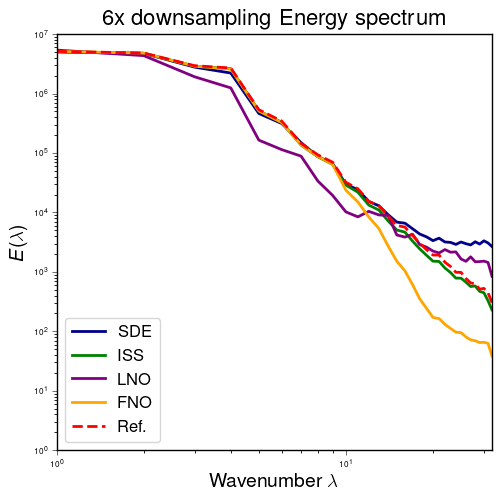

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic

def calculate_1d_energy_spectrum(u, v):
    N_samples, N = u.shape[0], u.shape[1]

    u_hat = np.fft.fft2(u, axes=(-2, -1))
    v_hat = np.fft.fft2(v, axes=(-2, -1))

    E_k_2d = 0.5 * (np.abs(u_hat)**2 + np.abs(v_hat)**2)
    E_k_avg_2d = np.mean(E_k_2d, axis=0) 

    k_x = np.fft.fftfreq(N, d=1.0/N)
    k_y = np.fft.fftfreq(N, d=1.0/N)
    
    kx, ky = np.meshgrid(k_x, k_y, indexing='ij')
    k_mag = np.sqrt(kx**2 + ky**2)

    k_bins = np.arange(0.5, N // 2 + 1, 1.0)
    k_flat = k_mag.ravel()
    E_flat = E_k_avg_2d.ravel()

    E_spectrum, bin_edges, _ = binned_statistic(
        k_flat, 
        E_flat, 
        statistic='sum', 
        bins=k_bins
    )

    k_values = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    return k_values, E_spectrum

u_pred = x_pred[0, :, 0, :, :]
v_pred = x_pred[0, :, 1, :, :]

u_pred1 = x_pred1[0, :, 0, :, :]
v_pred1 = x_pred1[0, :, 1, :, :]

u_pred2 = x_pred2[0, :, 0, :, :]
v_pred2 = x_pred2[0, :, 1, :, :]

u_pred3 = x_pred3[0, :, 0, :, :]
v_pred3 = x_pred3[0, :, 1, :, :]

u_ref = samples[0, :, 0, :, :]
v_ref = samples[0, :, 1, :, :]
N_grid = u_pred.shape[1]

lambda_pred, E_pred = calculate_1d_energy_spectrum(u_pred, v_pred)
lambda_pred1, E_pred1 = calculate_1d_energy_spectrum(u_pred1, v_pred1)
lambda_pred2, E_pred2 = calculate_1d_energy_spectrum(u_pred2, v_pred2)
lambda_pred3, E_pred3 = calculate_1d_energy_spectrum(u_pred3, v_pred3)
lambda_ref, E_ref = calculate_1d_energy_spectrum(u_ref, v_ref)

plt.figure(figsize=(5, 5))
ax = plt.gca()

plt.plot(lambda_pred, E_pred, color='darkblue', label='SDE', linewidth=2)
plt.plot(lambda_pred1, E_pred1, color='green', label='ISS', linewidth=2)
plt.plot(lambda_pred2, E_pred2, color='purple', label='LNO', linewidth=2)
plt.plot(lambda_pred3, E_pred3, color='orange', label='FNO', linewidth=2) 
plt.plot(lambda_ref, E_ref, color='red', linestyle='--', label='Ref.', linewidth=2)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'Wavenumber $\lambda$', fontsize=14)
plt.ylabel(r'$E(\lambda)$', fontsize=14)
plt.title('6x downsampling Energy spectrum', fontsize=16)

plt.xlim(1, N_grid // 2)
plt.ylim(1e0, 1e7) 

plt.legend(loc='lower left', frameon=True, fontsize=12) 

ax.spines['top'].set_visible(True) 
ax.spines['right'].set_visible(True)
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.spines['top'].set_linewidth(1)
ax.spines['right'].set_linewidth(1)

plt.grid(False)
plt.tight_layout()
plt.show()